<a href="https://colab.research.google.com/github/nadiduno/TCCFlyGrupo4/blob/main/tcc_evasaofly_g4cienciadedadosflyv13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 EVASÃO FLY, CAPÍTULO 2: os dados chegaram!

**Grupo Ada Lovelace (G4) · Turma Fly · diversiData.** Este notebook é a **continuação direta do V10 de vocês**: tudo que vocês deixaram pronto esperando os dados (o alvo desenhado, o molde do Pipeline, a seção "quando os dados chegarem") acontece AQUI, com os arquivos que a Fly mandou.

## O que chegou no zip (e o que descobrimos nele)

| Arquivo | O que é | Estado |
|---|---|---|
| `BDFLYG4.xlsx - Sheet1.csv` | A base das inscrições (2.380 candidatas x 165 colunas, todas as turmas) | ✅ usável (é a mais completa das 5 cópias do zip) |
| `BDFLYG4_backlogs.xlsx` | 12 abas (T12 a T23) com o STATUS das alunas nas turmas novas | ⚠️ metade das abas veio com **cabeçalho quebrado** |
| `dicionario_colunas_all.xlsx` | Dicionário de colunas | ✅ ajuda a entender os backlogs |

## Os 3 problemas que este notebook resolve (e documenta)

1. **164 colunas porque cada turma usou um formulário diferente:** a mesma pergunta escrita de até 5 jeitos. Solução: a **Estação de Harmonização** (conceito → lista de colunas-variantes → coalesce).
2. **Cabeçalhos quebrados nos backlogs:** em várias abas, a linha da primeira aluna virou nome de coluna. Solução: um **detector de coluna por vocabulário** (que também funciona quando chegarem abas novas!).
3. **As chaves `aluna_id` quase não casam** entre a base e os backlogs (só T12, T14 e parte de T20/T23 casam). Solução: usar o que casa, **medir e reportar** o que não casa, e levar pra Fly o pedido de uma chave consistente. Isso vira seção do TCC, não vergonha: **achado de qualidade de dados É resultado.**

> **Regra de privacidade deste notebook:** a base tem colunas de texto livre (endereços, relatos). A gente **nunca dá `head()` na base crua**: só na versão harmonizada, 100% não identificável. Dado é gente.


---
# Estação 0: ambiente e caminhos

**🔎 O que vamos fazer:** configurar onde estão os arquivos. No Colab, monte o Drive e aponte `PASTA` pra pasta do grupo; rodando local, aponte pra pasta extraída do zip.


In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, re, unicodedata

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)

np.random.seed(42)
plt.rcParams.update({'figure.figsize':(7,4.2),'figure.dpi':110,'font.size':11,
    'axes.grid':True,'grid.alpha':0.22,'axes.spines.top':False,'axes.spines.right':False,
    'axes.titlesize':13,'axes.titleweight':'bold'})
TEAL='#1da67a'; TEAL_D='#0f6e52'; AMBER='#e8a020'; CORAL='#d8562e'; NAVY='#0d1b2a'; SKY='#3a9ad9'; PURPLE='#7b5ea7'

# ===== CONFIGURE AQUI =====
# No Colab: descomente as 2 linhas do Drive e ajuste a PASTA
# from google.colab import drive; drive.mount('/content/drive')
# PASTA = '/content/drive/MyDrive/TCC-EvasaoFly/dados_fly'
PASTA = 'dados_fly'   # rodando local, a pasta extraida do zip
os.makedirs('dados', exist_ok=True)
print("Lendo de:", PASTA, "| Checkpoints em: dados/")

Lendo de: dados_fly | Checkpoints em: dados/


---
# Estação 1: CARREGAR (a base e os 12 backlogs)


In [ ]:
base = pd.read_csv(os.path.join(PASTA, 'BDFLYG4.xlsx - Sheet1.csv'))
base.columns = [c.strip() for c in base.columns]

# Perguntas que so diferiam por um espaco no fim viram colunas DUPLICADAS apos o strip.
# Nome igual = mesma pergunta em formularios diferentes -> juntamos por coalesce ja aqui:
if base.columns.duplicated().any():
    n_dup = int(base.columns.duplicated().sum())
    juntadas = {}
    for c in base.columns.unique():
        bloco = base.loc[:, base.columns == c]
        juntadas[c] = bloco.iloc[:, 0] if bloco.shape[1] == 1 else bloco.bfill(axis=1).iloc[:, 0]
    base = pd.DataFrame(juntadas)
    print(f"{n_dup} colunas duplicadas (mesma pergunta com espaco a mais) juntadas por coalesce.")
print("Base das inscricoes:", base.shape[0], "linhas x", base.shape[1], "colunas")
print("Turmas (turma_aba):", dict(base['turma_aba'].value_counts()))

xls_backlog = pd.ExcelFile(os.path.join(PASTA, 'BDFLYG4_backlogs.xlsx'))
backlogs = {aba: pd.read_excel(xls_backlog, sheet_name=aba) for aba in xls_backlog.sheet_names}
print("\nBacklogs carregados:", {aba: df.shape for aba, df in backlogs.items()})

FileNotFoundError: [Errno 2] No such file or directory: 'dados_fly/BDFLYG4.xlsx - Sheet1.csv'

In [ ]:
base.to_parquet('dados/01_base_bruta.parquet', index=False)
print("Checkpoint 01 salvo (a base como chegou; sem head por privacidade).")

NameError: name 'base' is not defined

---
# Estação 2 (a NOVA): HARMONIZAR AS 164 COLUNAS

**O problema:** cada turma usou um formulário. Idade existe em 2 colunas + 2 de nascimento; raça em 4; disponibilidade em 5... Sem juntar, cada variável fica ~80% vazia (o "vazio estrutural" que vocês JÁ tinham diagnosticado no V10!).

**A solução (o padrão pra guardar pra vida):** um **mapa de conceitos**. Cada conceito lista suas colunas-variantes; o `coalesce` pega, linha a linha, o primeiro valor não vazio; e um **filtro de vocabulário** joga fora resposta que não pertence à pergunta (achamos até endereço vazado na coluna LGBTQIAPN+ de uma turma: formulário desalinhado).


In [ ]:
def coalesce(df, colunas):
    """Primeiro valor nao-vazio entre as colunas-variantes, linha a linha."""
    existentes = [c for c in colunas if c in df.columns]
    s = pd.Series(np.nan, index=df.index, dtype='object')
    for c in existentes:
        s = s.fillna(df[c])
    return s

def filtra_vocab(s, permitidos):
    """Resposta fora do vocabulario da pergunta vira vazio (limpa formulario desalinhado)."""
    return s.where(s.isin(permitidos))

def norm(s):
    s = s.astype('string').str.strip()
    s = s.where(s.notna() & (s != ''))
    return s.astype(object).where(s.notna(), np.nan)   # object + np.nan: o sklearn agradece

MAPA = {
 'genero': ['Como você se identifica', 'Qual o seu gênero?', 'Em relação ao gênero, como você se identifica?'],
 'raca': ['Como você se identifica 2', 'Etnia: Como você se identifica', 'Como você se identifica?',
          'Em relação à raça, como você se identifica?'],
 'lgbt': ['Você faz parte da comunidade LGBTQIA+ ?', 'Você faz parte da comunidade LGBTQIAPN+?',
          'Você faz parte da comunidade LGBTQIAPN+ ?'],
 'idade_txt': ['Idade (Somente números)', 'Qual sua idade?'],
 'nascimento': ['Qual a sua data de nascimento?', 'Data de nascimento'],
 'escolaridade_txt': ['Grau de Escolaridade', 'Grau de escolaridade', 'Qual é o seu nível de escolaridade?'],
 'estado_txt': ['Estado que mora:', 'Estado/Região que mora:'],
 'renda_faixa': ['Renda familiar por pessoa:', 'Qual é a renda familiar aproximada por pessoa na sua casa?'],
 'pessoas_casa_txt': ['Quantas pessoas moram na sua casa?', 'Quantas pessoas moram na sua casa? (somente números)',
                      'Quantas pessoas moram na sua casa?.1'],
 'computador_txt': ['Possui computador?', 'Possui computador em casa?',
                    'Você possui computador para acompanhar as aulas e realizar a atividades do curso?',
                    'Qual dispositivo você pretende usar para acompanhar o curso?'],
 'internet_txt': ['Possui acesso ao Wi-Fi/Internet?', 'Você possui acesso a Internet?',
                  'Qual é a sua forma mais frequente de acesso à internet?'],
 'mae_cuidadora': ['Você possui filhos ou exerce papel de mãe/cuidadora?'],
 'disponibilidade_txt': ['Qual sua disponibilidade verdadeiramente de tempo para estudar e dedicar no curso:',
    'Quanto tempo você consegue dedicar ao curso por semana?'],
 'deficiencia': ['Você é uma pessoa com deficiência ?', 'Você é uma pessoa com deficiência?'],
}
# as variantes LONGAS de lgbt e disponibilidade (nomes gigantes): achamos por prefixo
extras_lgbt = [c for c in base.columns if c.startswith('Você faz parte da comunidade LGBTQIA+?')]
MAPA['lgbt'] += extras_lgbt
extras_disp = [c for c in base.columns if c.startswith('A gente sabe que a vida é bem corrida')
               or c.startswith('Sabemos que a rotina pode ser corrida')]
MAPA['disponibilidade_txt'] = MAPA['disponibilidade_txt'][:1] + extras_disp + MAPA['disponibilidade_txt'][1:]

H = pd.DataFrame({'aluna_id': base['aluna_id'], 'turma_aba': base['turma_aba'],
                  'status_aprovacao': norm(base['Aprovadas'])})
for conceito, variantes in MAPA.items():
    H[conceito] = norm(coalesce(base, variantes))
print("Conceitos harmonizados:", [c for c in H.columns if c not in ('aluna_id','turma_aba')])
print("\nPreenchimento apos o coalesce (%):")
print(((H.notna().mean()*100).round(0)).astype(int).to_string())

NameError: name 'base' is not defined

**📖 Como ler:** compare com o vazio estrutural do V10: conceitos que eram 4-5 colunas 80% vazias viraram UMA coluna com preenchimento alto. O coalesce costurou os formulários.

**🔎 Agora a padronização de cada conceito** (vocabulários unificados + números extraídos, incluindo a técnica de VOCÊS de recuperar idade escondida em data colada):


In [ ]:
ANO_REF = 2026

H['genero'] = H['genero'].replace({'Feminino':'Mulher Cis','Mulher':'Mulher Cis','Mulher Trans':'Mulher Transgênero',
                                   'Não-Binário':'Não-binárie','Não-Binárie':'Não-binárie'})
H['genero'] = filtra_vocab(H['genero'], ['Mulher Cis','Mulher Transgênero','Não-binárie','Outro'])
H['raca'] = filtra_vocab(H['raca'], ['Preta','Parda','Branca','Indígena','Amarela'])
H['lgbt'] = filtra_vocab(H['lgbt'], ['Sim','Não','Prefiro não responder'])
H['mae_cuidadora'] = filtra_vocab(H['mae_cuidadora'], ['Sim','Não'])
H['deficiencia'] = filtra_vocab(H['deficiencia'], ['Sim','Não'])

# idade: numero direto OU recuperada da "data colada" (tecnica do V10) OU do nascimento
idade = pd.to_numeric(H['idade_txt'], errors='coerce')
mask_data = idade > 1_000_000                       # ex.: 27081982 = 27/08/1982
idade.loc[mask_data] = ANO_REF - (idade[mask_data] % 10000)
nasc = pd.to_datetime(H['nascimento'], errors='coerce', dayfirst=True)
idade = idade.fillna(ANO_REF - nasc.dt.year)
H['idade'] = idade.where((idade >= 14) & (idade <= 80))

esc_map = {'Ensino Fundamental Incompleto':1,'Ensino Fundamental Completo':2,'Ensino Médio Incompleto':2,
           'Ensino Médio Completo':3,'Ensino Técnico':3,'Ensino Superior Incompleto (Graduação)':4,
           'Ensino Superior Incompleto':4,'Ensino Superior Completo (Graduação)':5,'Ensino Superior Completo':5,
           'Pós-graduação':6,'Pós-graduação (Especialização, Mestrado ou Doutorado)':6}
H['escolaridade'] = H['escolaridade_txt'].map(esc_map)

renda_map = {'Menos de 1 salário mínimo por pessoa':0,'Menos de 1 salário mínimo':0,
             'De 1 a 2 salários mínimos por pessoa':1,'Entre 1 e 2 salários mínimos':1,
             'Entre 2 e 3 salários mínimos':2,'De 3 a 5 salários mínimos por pessoa':2,
             'Mais de 3 salários mínimos':3,'Mais de 5 salários mínimos por pessoa':3}
H['renda_ord'] = H['renda_faixa'].map(renda_map)

disp_map = {'Até 1 hora por dia':0.5,'1 a 2 horas por dia':1.5,'2 a 3 horas por dia':2.5,
            '3 a 5 horas por dia':4.0,'3 horas ou mais por dia':4.0,'Mais de 5 horas por dia':6.0,
            'Somente aos finais de semana':0.7,'Até 5 horas':0.7,'5 a 10 horas':1.5,'Mais de 10 horas':2.0}
H['disponibilidade_h'] = H['disponibilidade_txt'].map(disp_map)

def tem_pc(v):
    if pd.isna(v): return np.nan
    v = str(v).lower()
    if 'notebook' in v or 'computador' in v or v == 'sim': return 'Sim'
    if v in ('não','nao'): return 'Não'
    return 'Não' if ('celular' in v or 'smartphone' in v or 'tablet' in v) else np.nan
H['tem_computador'] = H['computador_txt'].map(tem_pc)
H['tem_internet'] = H['internet_txt'].map(lambda v: np.nan if pd.isna(v)
                    else ('Não' if str(v).strip().lower() in ('não','nao') else 'Sim'))

H['pessoas_casa'] = pd.to_numeric(H['pessoas_casa_txt'], errors='coerce')
H['pessoas_casa'] = H['pessoas_casa'].where((H['pessoas_casa'] >= 1) & (H['pessoas_casa'] <= 15))

SIGLA = {'AC':'N','AM':'N','AP':'N','PA':'N','RO':'N','RR':'N','TO':'N','AL':'NE','BA':'NE','CE':'NE',
         'MA':'NE','PB':'NE','PE':'NE','PI':'NE','RN':'NE','SE':'NE','DF':'CO','GO':'CO','MT':'CO','MS':'CO',
         'ES':'SE','MG':'SE','RJ':'SE','SP':'SE','PR':'S','RS':'S','SC':'S'}
UF_NOME = {'acre':'AC','amazonas':'AM','amapa':'AP','para':'PA','rondonia':'RO','roraima':'RR','tocantins':'TO',
    'alagoas':'AL','bahia':'BA','ceara':'CE','maranhao':'MA','paraiba':'PB','pernambuco':'PE','piaui':'PI',
    'rio grande do norte':'RN','sergipe':'SE','distrito federal':'DF','goias':'GO','mato grosso do sul':'MS',
    'mato grosso':'MT','espirito santo':'ES','minas gerais':'MG','rio de janeiro':'RJ','sao paulo':'SP',
    'parana':'PR','rio grande do sul':'RS','santa catarina':'SC'}
def regiao(v):
    if pd.isna(v): return np.nan
    t = ''.join(ch for ch in unicodedata.normalize('NFKD', str(v).lower()) if not unicodedata.combining(ch))
    m = re.search(r'\(([a-z]{2})\)', t)
    if m and m.group(1).upper() in SIGLA: return SIGLA[m.group(1).upper()]
    if t.strip().upper() in SIGLA: return SIGLA[t.strip().upper()]
    for nome, sg in UF_NOME.items():
        if nome in t: return SIGLA[sg]
    return np.nan
H['regiao'] = H['estado_txt'].map(regiao)

harm = H.drop(columns=['idade_txt','nascimento','escolaridade_txt','estado_txt','renda_faixa',
                       'pessoas_casa_txt','computador_txt','internet_txt','disponibilidade_txt'])
print("A BASE HARMONIZADA (esta pode dar head: zero dado identificavel):")
harm.head(8)

NameError: name 'H' is not defined

In [ ]:
harm.to_parquet('dados/02_harmonizada.parquet', index=False)
print("Checkpoint 02 salvo. Preenchimento final (%):")
print(((harm.notna().mean()*100).round(0)).astype(int).sort_values(ascending=False).to_string())

NameError: name 'harm' is not defined

---
# Estação 3: O ALVO `evadiu`, agora com as 3 fontes

O desenho continua o do V10 de vocês, agora completado pelos backlogs:

1. **Fonte 1 (turmas antigas, na própria base):** `status_aprovacao`: **Formada → evadiu=0**; **Aprovada (entrou e não formou) → evadiu=1**; **Não aprovada → fora do universo** (não é evasão, é seleção).
2. **Fonte 2 (turmas novas, backlogs):** status/desligamento por aba, MAS metade das abas veio com cabeçalho quebrado. Solução: o **detector por vocabulário** abaixo.
3. **Reconciliação:** quando as duas fontes falam da mesma aluna, **o backlog vence** (é mais recente).

## O detector de coluna por vocabulário

**🔎 A ideia:** mesmo sem nome de coluna confiável, o CONTEÚDO entrega o que ela é. Uma coluna cheia de `Ativo/Desligada/Evasão/Formada` é status; cheia de `Sim/Não` perto de "desligamento" é assinatura. E o detector também protege o futuro: chegou aba nova bagunçada? Ele resolve.


In [ ]:
VOCAB_STATUS = {'ativo','ativa','desligada','desligado','evasão','evasao','formada','formado','concluída','concluida'}
NEGATIVOS = {'desligada','desligado','evasão','evasao'}   # status que significam evadiu=1
POSITIVOS = {'ativo','ativa','formada','formado','concluída','concluida'}

def detecta_status(df):
    """Retorna (serie_evadiu, relatorio) a partir de QUALQUER aba de backlog."""
    relatorio = []
    evadiu = pd.Series(np.nan, index=df.index, dtype='float')
    for c in df.columns:
        if c == 'aluna_id': continue
        vals = df[c].dropna().astype(str).str.strip().str.lower()
        if len(vals) == 0: continue
        frac_status = vals.isin(VOCAB_STATUS).mean()
        if frac_status >= 0.5:                       # e uma coluna de STATUS
            ev = vals.map(lambda v: 1.0 if v in NEGATIVOS else (0.0 if v in POSITIVOS else np.nan))
            evadiu = evadiu.fillna(ev.reindex(df.index))
            relatorio.append(f"status em '{str(c)[:20]}' ({frac_status:.0%} do vocab)")
    # sinal reforco: coluna explicita de desligamento assinado
    for c in df.columns:
        if 'desligamento' in str(c).lower():
            ev = df[c].astype(str).str.strip().str.lower().map(lambda v: 1.0 if v == 'sim' else np.nan)
            evadiu = evadiu.fillna(ev)
            # quem tem matricula mas NAO assinou desligamento e nao tem outro status: ativa (0)
            evadiu = evadiu.fillna(0.0) if 'Assinou Matricula' in df.columns else evadiu
            relatorio.append(f"desligamento em '{str(c)[:24]}'")
    return evadiu, relatorio

linhas = []
for aba, df in backlogs.items():
    ev, rel = detecta_status(df)
    achou = ev.notna().sum()
    for aluna, v in zip(df['aluna_id'], ev):
        if pd.notna(v): linhas.append({'aluna_id': aluna, 'aba_backlog': aba, 'evadiu_backlog': int(v)})
    print(f"{aba:6s}: {len(df):3d} alunas | com status: {achou:3d} | {'; '.join(rel) if rel else 'SEM sinal de status (pendencia pra Fly)'}")
alvo_backlog = pd.DataFrame(linhas).drop_duplicates('aluna_id')
print(f"\nTotal com status nos backlogs: {len(alvo_backlog)} alunas | evasao entre elas: {alvo_backlog['evadiu_backlog'].mean()*100:.0f}%")

NameError: name 'backlogs' is not defined

**📖 Como ler:** as abas com sinal renderam o alvo; as SEM sinal (só `aluna_id`, sem status) viram **pendência documentada**: a Fly precisa mandar o status dessas turmas. E cada aba quebrada perdeu ~1 aluna (a linha que virou cabeçalho): registrado.

## Juntar as 3 fontes e medir a cobertura das chaves


In [ ]:
alvo = harm.merge(alvo_backlog, on='aluna_id', how='left')

# fonte 1: o desenho do V10 (turmas antigas)
alvo['evadiu_status'] = alvo['status_aprovacao'].map({'Formada':0.0,'Formadas':0.0,'Aprovada':1.0,'Aprovadas':1.0})

# reconciliar: backlog (mais recente) vence
alvo['evadiu'] = alvo['evadiu_backlog'].combine_first(alvo['evadiu_status'])

# cobertura das chaves: o problema numero 3, medido
ids_backlog_todos = set(pd.concat([df['aluna_id'] for df in backlogs.values()]).dropna())
casam = len(ids_backlog_todos & set(harm['aluna_id']))
print(f"COBERTURA DAS CHAVES: {len(ids_backlog_todos)} alunas nos backlogs, {casam} casam com a base ({casam/len(ids_backlog_todos):.0%}).")
print("As que nao casam tem STATUS mas nao tem PERFIL: sem chave comum, nao entram no modelo.")
print("(pedido oficial pra Fly: a MESMA chave aluna_id nos dois arquivos)\n")

universo = alvo[alvo['evadiu'].notna()].copy()
universo['evadiu'] = universo['evadiu'].astype(int)
print(f"UNIVERSO DO MODELO: {len(universo)} alunas que ENTRARAM e tem desfecho conhecido")
print(f"  evadiu=1: {int(universo['evadiu'].sum())} | concluiu/ativa=0: {int((1-universo['evadiu']).sum())}")
print(f"  taxa de evasao: {universo['evadiu'].mean()*100:.1f}%")
print("\nPor turma:")
print(universo.groupby('turma_aba')['evadiu'].agg(['count','mean']).round(2).to_string())

universo.to_parquet('dados/03_universo_com_alvo.parquet', index=False)
print("\nCheckpoint 03 salvo.")

NameError: name 'harm' is not defined

---
# Estação 4: EDA do universo (as hipóteses de vocês, agora com alvo de verdade)

As hipóteses do V10, formalizadas: **H1** acesso digital precário aumenta evasão; **H2** sobrecarga de cuidado (mãe/cuidadora) aumenta evasão; **H3** menos disponibilidade real de horas, mais evasão; **H4** renda por pessoa menor, mais evasão.

**🔎 Primeiro o alvo** (a decisão do stratify e das métricas nasce aqui):


In [ ]:
print("O alvo:", dict(universo['evadiu'].value_counts()))
print("Proporcao:", dict(universo['evadiu'].value_counts(normalize=True).round(3)))
print("-> desbalanceado o suficiente para: stratify na separacao + F1/recall na regua (nada de acuracia sozinha)")

NameError: name 'universo' is not defined

NameError: name 'universo' is not defined

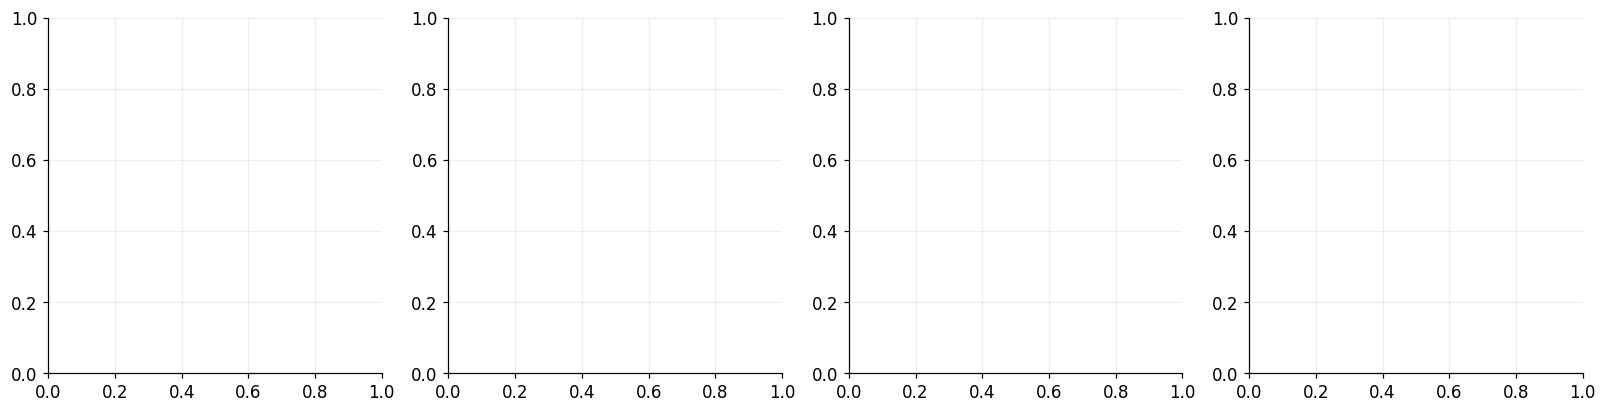

In [ ]:
def taxa_por(col, minimo=8):
    t = universo.groupby(col, observed=True)['evadiu'].agg(n='count', taxa='mean')
    t = t[t['n'] >= minimo]
    t['taxa'] *= 100
    return t.sort_values('taxa')

fig, axes = plt.subplots(1, 4, figsize=(18,4.2))
for ax, col, titulo in [(axes[0],'tem_computador','H1: computador'),(axes[1],'mae_cuidadora','H2: mae/cuidadora'),
                        (axes[2],'renda_ord','H4: faixa de renda (0=<1SM)'),(axes[3],'regiao','regiao')]:
    t = taxa_por(col)
    ax.bar(t.index.astype(str), t['taxa'], color=PURPLE, edgecolor='white')
    for i,(tx,n) in enumerate(zip(t['taxa'], t['n'])): ax.text(i, tx+1, f'{tx:.0f}%\n(n={n})', ha='center', fontsize=8.5)
    ax.set_title(titulo); ax.set_ylabel('% evasao')
plt.tight_layout(); plt.show()

In [ ]:
# H3: disponibilidade (numerica) entre quem evadiu e quem nao
fig, ax = plt.subplots(figsize=(7,4))
dados_disp = universo.dropna(subset=['disponibilidade_h'])
ax.hist(dados_disp.loc[dados_disp['evadiu']==0,'disponibilidade_h'], bins=8, alpha=0.65, label='concluiu/ativa', color=TEAL, edgecolor='white')
ax.hist(dados_disp.loc[dados_disp['evadiu']==1,'disponibilidade_h'], bins=8, alpha=0.65, label='evadiu', color=CORAL, edgecolor='white')
ax.set_xlabel('horas/dia declaradas na inscricao'); ax.set_title('H3: disponibilidade declarada x evasao')
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# o teste do chi2 (que voces ja usavam) + V de Cramer (a forca, de 0 a 1)
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    tabela = pd.crosstab(x, y)
    if tabela.shape[0] < 2 or tabela.shape[1] < 2: return np.nan, np.nan
    chi2_stat, p, _, _ = chi2_contingency(tabela)
    n = tabela.values.sum(); k = min(tabela.shape) - 1
    return np.sqrt(chi2_stat/(n*k)), p

print(f"{'variavel':18s} {'V de Cramer':>12s} {'p-valor':>9s}  leitura")
for c in ['tem_computador','mae_cuidadora','tem_internet','raca','regiao','lgbt','deficiencia']:
    sub = universo.dropna(subset=[c])
    v, p = cramers_v(sub[c], sub['evadiu'])
    if np.isnan(v): print(f"{c:18s} {'n insuf.':>12s}"); continue
    forca = 'forte' if v>=0.5 else ('media' if v>=0.3 else ('fraca' if v>=0.1 else 'quase nula'))
    sig = 'significativa' if p < 0.05 else 'pode ser acaso (n pequeno)'
    print(f"{c:18s} {v:12.3f} {p:9.3f}  {forca}, {sig}")
print("\nCom n pequeno, p-valores altos NAO significam 'nao existe': significam 'ainda nao da pra afirmar'.")
print("Escrevam isso no TCC com essas palavras: e honestidade estatistica.")

---
# Estação 5: SEPARAR (com stratify: decisão consciente) e MODELAR

A régua relembrada em 4 linhas: **os quatro destinos** (VN/FP/FN/VP); **acurácia mente no desbalanceado** (o baseline prova na tabela); **recall** = das que evadiram, quantas o modelo achou (o passou-batido, que aqui é uma mulher perdendo a formação); **F1** ordena a tabela. No nosso problema, **recall pesa mais**: alarme falso é uma conversa de acolhimento a mais; passou-batido é uma evasão que ninguém tentou evitar.

**🔎 Atenção ao tamanho:** o universo é pequeno, então: `stratify` obrigatório, validação cruzada em TUDO, e humildade nas conclusões (o modelo é um protótipo que melhora a cada turma com status novo).


In [ ]:
c_num = ['idade','escolaridade','renda_ord','disponibilidade_h','pessoas_casa']
c_cat = ['raca','tem_computador','tem_internet','mae_cuidadora','regiao','lgbt','deficiencia']
Xu = universo[c_num + c_cat]
yu = universo['evadiu']

X_tr, X_te, y_tr, y_te = train_test_split(Xu, yu, test_size=0.25, random_state=42, stratify=yu)
print("Treino:", X_tr.shape, "| Teste:", X_te.shape)
print(f"Evasao: {y_tr.mean()*100:.0f}% no treino | {y_te.mean()*100:.0f}% no teste (stratify ok)")

preparo = ColumnTransformer([
    ('num', Pipeline([('preencher', SimpleImputer(strategy='median')),
                      ('escala', StandardScaler())]), c_num),
    ('cat', Pipeline([('preencher', SimpleImputer(strategy='constant', fill_value='Nao respondeu')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), c_cat)])
print("\nPreparo no Pipeline: mediana e 'Nao respondeu' aprendidos/aplicados SO no treino, ate na validacao cruzada.")

In [ ]:
modelos = {
    'Baseline (mais comum)': DummyClassifier(strategy='most_frequent'),
    'Regressao Logistica': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Arvore (rasa)': DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5,
                                            class_weight='balanced', random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=2, random_state=42),
}
linhas = []
for nome, m in modelos.items():
    fluxo = Pipeline([('preparo', preparo), ('modelo', m)]).fit(X_tr, y_tr)
    p = fluxo.predict(X_te)
    linhas.append({'modelo':nome,
        'acuracia': round(accuracy_score(y_te,p),3),
        'precisao_evadiu': round(precision_score(y_te,p,zero_division=0),3),
        'recall_evadiu': round(recall_score(y_te,p,zero_division=0),3),
        'F1_evadiu': round(f1_score(y_te,p,zero_division=0),3)})
tab = pd.DataFrame(linhas).sort_values('F1_evadiu', ascending=False).reset_index(drop=True)
tab

**📖 Como ler:** a linha do baseline prova a armadilha da acurácia; os modelos com `class_weight='balanced'` sobem porque pagam caro por errar a minoria. Com n pequeno, os números balançam entre execuções: por isso a decisão final usa a **validação cruzada** do GridSearch, não uma prova só.


In [ ]:
fluxo_rf = Pipeline([('preparo', preparo),
                     ('modelo', RandomForestClassifier(class_weight='balanced', random_state=42))])
grade = {'modelo__n_estimators':[200,400], 'modelo__max_depth':[3,5,7], 'modelo__min_samples_leaf':[3,5,8]}
busca = GridSearchCV(fluxo_rf, grade, cv=5, scoring='f1', n_jobs=-1)
busca.fit(X_tr, y_tr)
print("Melhor combinacao:", busca.best_params_)
print(f"F1 na validacao cruzada: {busca.best_score_:.3f}")
p_final = busca.best_estimator_.predict(X_te)
print(f"No teste, UMA vez: F1 {f1_score(y_te,p_final):.3f} | recall {recall_score(y_te,p_final):.3f}")

In [ ]:
cm = confusion_matrix(y_te, p_final)
fig, ax = plt.subplots(figsize=(5.6,4.6))
ax.imshow(cm, cmap='Greens'); ax.grid(False)
rot = [['Verdadeiro Negativo\n(seguiu, modelo acertou)','Falso Positivo\n(alarme falso: uma conversa a mais)'],
       ['Falso Negativo\n(evadiu e PASSOU BATIDO)','Verdadeiro Positivo\n(risco detectado a tempo)']]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]}\n{rot[i][j]}", ha='center', va='center', fontsize=9,
                color='white' if cm[i,j]>cm.max()/2 else '#0d1b2a')
ax.set_xticks([0,1]); ax.set_xticklabels(['previu: segue','previu: evade'])
ax.set_yticks([0,1]); ax.set_yticklabels(['real: seguiu','real: evadiu'])
ax.set_title('Os quatro destinos no campeao')
plt.tight_layout(); plt.show()

In [ ]:
# quem mais pesa na previsao (o mapa de onde agir)
nomes_feat = busca.best_estimator_.named_steps['preparo'].get_feature_names_out()
imp = pd.Series(busca.best_estimator_.named_steps['modelo'].feature_importances_, index=nomes_feat)
top = imp.sort_values().tail(10)
fig, ax = plt.subplots(figsize=(8,4.4))
ax.barh([n.replace('num__','').replace('cat__','') for n in top.index], top.values, color=TEAL, edgecolor='white')
ax.set_title('O que mais pesa no risco de evasao (importancia da floresta)')
plt.tight_layout(); plt.show()
print("Leitura pro TCC: os fatores do topo sao onde a Fly pode AGIR (emprestimo de notebook,")
print("horarios alternativos, rede de apoio ao cuidado). Modelo social bom aponta ACAO.")

In [ ]:
import joblib
joblib.dump(busca.best_estimator_, 'dados/modelo_evasao_G4.joblib')
print("Modelo salvo: dados/modelo_evasao_G4.joblib (o cerebro pronto pra camada de IA da mentoria).")
print("\nA pasta do projeto:")
for f in sorted(os.listdir('dados')):
    print(f"  dados/{f:34s} {os.path.getsize(f'dados/{f}')/1024:8.0f} KB")

---
# ✅ Resumo do capítulo 2 (e o que levar pra mentoria)

**O que este notebook entregou:**
1. **Harmonização** das 164 colunas em 15 conceitos limpos (coalesce + filtro de vocabulário), sem imprimir nenhum dado pessoal.
2. **O alvo `evadiu` de 3 fontes** reconciliadas (o desenho do V10 + os backlogs decifrados pelo detector de vocabulário).
3. **O relatório de cobertura das chaves** (o achado de qualidade de dados que vai pro TCC e pro pedido oficial à Fly).
4. **EDA com alvo real:** as hipóteses de vocês testadas, com chi2 + V de Cramér e a honestidade do n pequeno.
5. **Modelo completo:** Pipeline sem vazamento, baseline, class_weight, GridSearch com validação cruzada, matriz dos quatro destinos e o mapa de importâncias que aponta ONDE AGIR.

**O pedido pra Fly (levem por escrito):**
- A MESMA chave `aluna_id` na base de inscrições e nos backlogs (hoje só T12/T14/T20-parcial casam);
- O status das turmas cujas abas vieram sem sinal (T13* formada?, T15, T16A/B, T17, T18, T19, T22, T23 parciais);
- Os backlogs com cabeçalho na primeira linha (as abas quebradas perderam ~1 aluna cada).

**E a frase do projeto:** cada Falso Negativo é uma mulher que a gente poderia ter acolhido antes. O modelo existe pra chegar ANTES da evasão, nunca pra rotular ninguém. 💛
